# Load data & setup:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load raw data
df = pd.read_csv('../data/raw/energy_raw.csv')
df['date'] = df['date'].str.replace(
    r'(\d{4}-\d{2}-\d{2})(\d{2}:)',
    r'\1 \2',
    regex=True
)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Raw data loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Raw data loaded: 19735 rows, 29 columns


# Before snapshot (DS401):

BEFORE PREPROCESSING — SNAPSHOT

Shape: (19735, 29)
Missing values:
date           0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
Appliances     0

Duplicates: 0

Noise columns (rv1, rv2) present: True

Target stats BEFORE cleaning:
count    19735.00
mean        97.69
std        102.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max       1080.00
Name: Appliances, dtype: float64


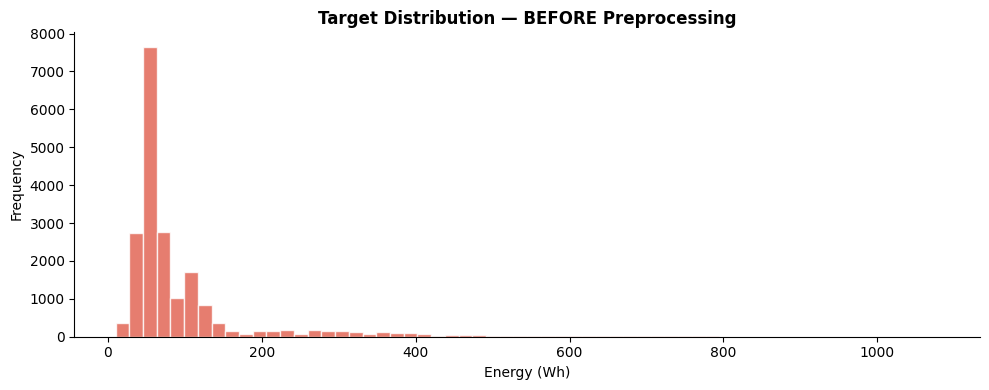

In [3]:
print("="*55)
print("BEFORE PREPROCESSING — SNAPSHOT")
print("="*55)

print(f"\nShape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum().to_string()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nNoise columns (rv1, rv2) present: {'rv1' in df.columns and 'rv2' in df.columns}")
print(f"\nTarget stats BEFORE cleaning:")
print(df['Appliances'].describe().round(2))

# Save before distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['Appliances'], bins=60, color='#E05C4B', alpha=0.8, edgecolor='white')
ax.set_title('Target Distribution — BEFORE Preprocessing', fontweight='bold')
ax.set_xlabel('Energy (Wh)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/07_before_distribution.png', bbox_inches='tight')
plt.show()

# Drop noise columns:

In [4]:
# drop noise columns
df.drop(columns=['rv1', 'rv2'], inplace=True)
print("After dropping noise columns (rv1, rv2):"
      f"\nShape: {df.shape}"
      f"\nColumns: {df.columns.tolist()}"
      )


After dropping noise columns (rv1, rv2):
Shape: (19735, 27)
Columns: ['date', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Appliances']


# Extract time features from date:

In [5]:
df["hour"]= df["date"].dt.hour
df["day_of_week"]= df["date"].dt.dayofweek
df["month"]= df["date"].dt.month
df["is_weekend"]= df["day_of_week"].isin([5,6]).astype(int)
df["day_of_year"]= df["date"].dt.dayofyear


In [6]:

# cyclice encoding for Time (hour &day)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print(f"Time features added: hour, day_of_week, month, is_weekend, day_of_year")
print(f"Cyclical encoding added: hour_sin, hour_cos, dow_sin, dow_cos")
print(f"Shape now: {df.shape}")

Time features added: hour, day_of_week, month, is_weekend, day_of_year
Cyclical encoding added: hour_sin, hour_cos, dow_sin, dow_cos
Shape now: (19735, 36)


## Outlier capping on target (IQR method):

In [ ]:

Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = len(df[(df["Appliances"]<lower_bound)|(df["Appliances"]>upper_bound)])

# Cap outliers instead of removing (preserves time continuity)
df["Appliances"]=df["Appliances"].clip(lower=lower_bound, upper=upper_bound)

print(f"Outlier Capping (IQR Method):")
print(f"  Lower bound: {lower_bound:.1f} Wh")
print(f"  Upper bound: {upper_bound:.1f} Wh")
print(f"  Outliers capped: {outliers_count} rows ({outliers_count/len(df)*100:.1f}%)")
print(f"  Rows preserved: {len(df)} (no data removed — time-series continuity maintained)")



Outlier Capping (IQR Method):
  Lower bound: -25.0 Wh
  Upper bound: 175.0 Wh
  Outliers capped: 2138 rows (10.8%)
  Rows preserved: 19735 (no data removed — time-series continuity maintained)


 ## Create lag features:

In [8]:
print("Creating lag features...")

df["lag_1"] = df["Appliances"].shift(1) #10 min lag
df["lag_6"] = df["Appliances"].shift(6) #1 hour lag (6*10min)
df["lag_12"] = df["Appliances"].shift(12) #2 hour lag (12*10min)
df["lag_144"] =df["Appliances"].shift(144) #1 day lag (144*10min)
df["lag_1008"] = df["Appliances"].shift(1008) #1 week lag (1008*10min)

print("Creating rolling window...")

df["rolling_mean_6"] = df["Appliances"].shift(1).rolling(window=6).mean() #1 hour rolling mean
df["rolling_mean_144"] = df["Appliances"].shift(1).rolling(window=144).mean() #1 day rolling mean
df["rolling_std_6"]= df["Appliances"].shift(1).rolling(window=6).std() #1 hour rolling std


print("Lag features created:")
print("  lag_1   → 10 minutes ago")
print("  lag_6   → 1 hour ago")
print("  lag_12  → 2 hours ago")
print("  lag_144 → 24 hours ago (1 day)")
print("  lag_1008→ 1 week ago")
print("  rolling_mean_6   → 1hr rolling average")
print("  rolling_mean_144 → 24hr rolling average")
print("  rolling_std_6    → 1hr rolling std dev")

# Drop rows with NaN from lag creation
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nRows dropped due to NaN from lags: {rows_before - len(df)}")
print(f"Final shape after lag features: {df.shape}")

Creating lag features...
Creating rolling window...
Lag features created:
  lag_1   → 10 minutes ago
  lag_6   → 1 hour ago
  lag_12  → 2 hours ago
  lag_144 → 24 hours ago (1 day)
  lag_1008→ 1 week ago
  rolling_mean_6   → 1hr rolling average
  rolling_mean_144 → 24hr rolling average
  rolling_std_6    → 1hr rolling std dev

Rows dropped due to NaN from lags: 1008
Final shape after lag features: (18727, 44)


## Train/test split (time-ordered, no shuffle):

Train set: 14981 rows, 44 columns
Test set: 3746 rows, 44 columns


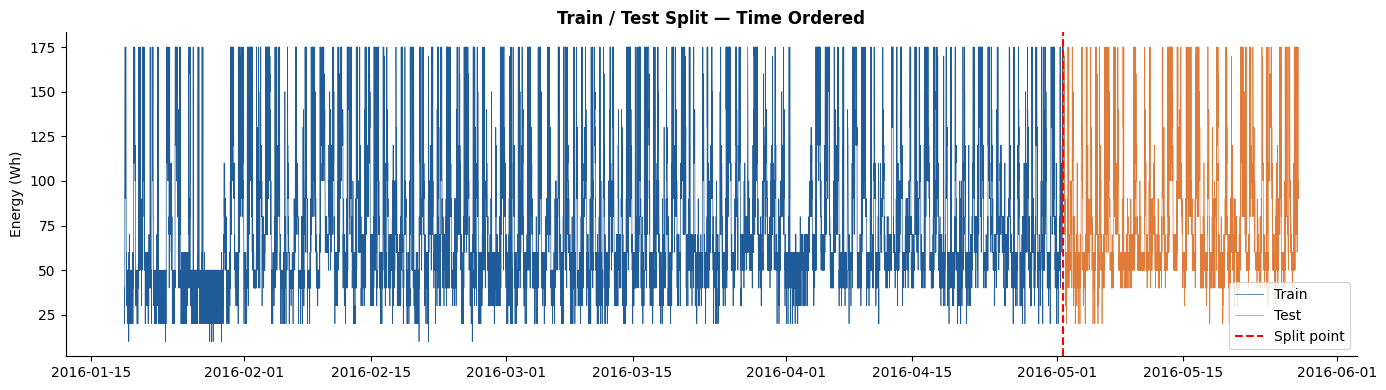

In [9]:
split_ratio = 0.8
split_idx= int(len(df) * split_ratio)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['date'], train_df['Appliances'], color='#1F5C99', label='Train', linewidth=0.5)
ax.plot(test_df['date'],  test_df['Appliances'],  color='#E07B39', label='Test',  linewidth=0.5)
ax.axvline(test_df['date'].iloc[0], color='red', linestyle='--', linewidth=1.5, label='Split point')
ax.set_title('Train / Test Split — Time Ordered', fontweight='bold')
ax.set_ylabel('Energy (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/08_train_test_split.png', bbox_inches='tight')
plt.show()

## Feature scaling (MinMaxScaler):

In [ ]:

feature_droped=["Appliances", "date"]

feature_cols = [col for col in df.columns if col not in feature_droped]

scaler_X=MinMaxScaler()
scaler_Y=MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[feature_cols])
X_test = scaler_X.transform(test_df[feature_cols])

y_train = scaler_Y.fit_transform(train_df[["Appliances"]])
y_test = scaler_Y.transform(test_df[["Appliances"]])

print(f"Scaling applied (MinMaxScaler):")
print(f"  Scaler fit on TRAIN only (no data leakage)")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test  shape: {X_test.shape}")
print(f"  y_train range: {y_train.min():.3f} → {y_train.max():.3f}")
print(f"  y_test  range: {y_test.min():.3f} → {y_test.max():.3f}")

# Save scalers for later use in Streamlit app
with open('../models/scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('../models/scaler_Y.pkl', 'wb') as f:
    pickle.dump(scaler_Y, f)

print("\nScalers saved to models/")

Scaling applied (MinMaxScaler):
  Scaler fit on TRAIN only (no data leakage)
  X_train shape: (14981, 42)
  X_test  shape: (3746, 42)
  y_train range: 0.000 → 1.000
  y_test  range: 0.061 → 1.000

Scalers saved to models/


## After snapshot & comparison (DS401):

AFTER PREPROCESSING — SNAPSHOT (DS401 Requirement)

Final shape: (18727, 44)
Missing values after cleaning: 0
New features added: 16 columns

Target stats AFTER capping:
count    18727.00
mean        78.74
std         42.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max        175.00
Name: Appliances, dtype: float64


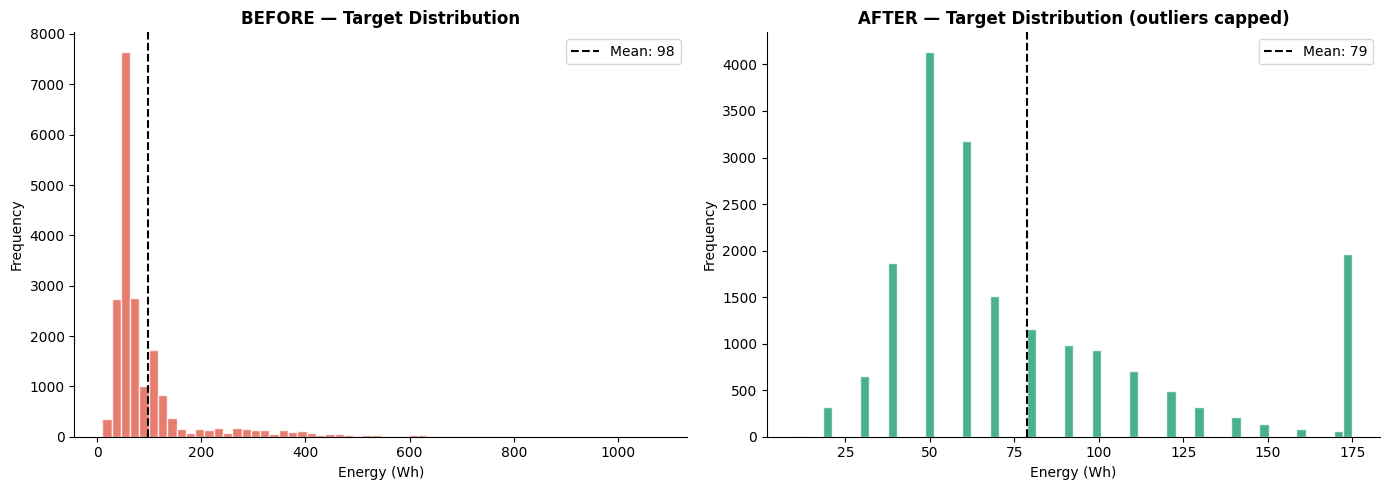

Before/After comparison saved! (DS401 rubric satisfied)


In [11]:
print("="*55)
print("AFTER PREPROCESSING — SNAPSHOT (DS401 Requirement)")
print("="*55)

processed_df = train_df.copy()
print(f"\nFinal shape: {df.shape}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"New features added: {df.shape[1] - 28} columns")

print(f"\nTarget stats AFTER capping:")
print(df['Appliances'].describe().round(2))

# Before vs After distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_df = pd.read_csv('../data/raw/energy_raw.csv')
axes[0].hist(raw_df['Appliances'], bins=60, color='#E05C4B', alpha=0.8, edgecolor='white')
axes[0].set_title('BEFORE — Target Distribution', fontweight='bold')
axes[0].set_xlabel('Energy (Wh)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(raw_df['Appliances'].mean(), color='black', linestyle='--', label=f"Mean: {raw_df['Appliances'].mean():.0f}")
axes[0].legend()

axes[1].hist(df['Appliances'], bins=60, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title('AFTER — Target Distribution (outliers capped)', fontweight='bold')
axes[1].set_xlabel('Energy (Wh)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Appliances'].mean(), color='black', linestyle='--', label=f"Mean: {df['Appliances'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/09_before_after_comparison.png', bbox_inches='tight')
plt.show()
print("Before/After comparison saved! (DS401 rubric satisfied)")

##  Save processed data:

In [13]:
# Save processed datasets
df.to_csv('../data/processed/energy_processed.csv', index=False)
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

# Save scaled arrays
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy',  X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)

# Save feature column names for later
import json
with open('../data/processed/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("All processed files saved:")
print("  data/processed/energy_processed.csv")
print("  data/processed/train.csv")
print("  data/processed/test.csv")
print("  data/processed/X_train.npy  &  X_test.npy")
print("  data/processed/y_train.npy  &  y_test.npy")
print("  data/processed/feature_cols.json")


All processed files saved:
  data/processed/energy_processed.csv
  data/processed/train.csv
  data/processed/test.csv
  data/processed/X_train.npy  &  X_test.npy
  data/processed/y_train.npy  &  y_test.npy
  data/processed/feature_cols.json
